# LIBERO 批量物体位置扰动工具

这个 notebook 用于对同一个 task_suite 下的 task_id 0-9 进行批量物体位置扰动。

功能：
1. 选择是否对 Obj of interest 进行扰动（如果否，则从其他物体中选择）
2. 控制扰动物体的数量
3. 控制扰动方向和大小
4. 将扰动后的 BDDL 文件保存到指定路径


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from libero.libero import benchmark
from libero.libero.envs import OffScreenRenderEnv
import os
from libero.libero import get_libero_path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import libero.libero.envs.bddl_utils as BDDLUtils
from libero.libero.envs.bddl_utils import generate_bddl_from_parsed_problem
from utils_displacement import (
    modify_object_region_position, 
    get_libero_image,
    select_objects_to_perturb,
    get_perturbation_values,
    apply_perturbations,
    save_perturbed_bddl,
    generate_init_states_for_bddl
)
import random
from pathlib import Path
from typing import List, Dict, Tuple, Union
import copy


11111111111111111111111


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /hdd/zijianwang/openpi/examples/libero/.venv/lib/python3.8/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)


## 配置参数

在这里设置所有的扰动参数：


In [12]:
# ============= 基础配置 =============
task_suite_name = "libero_10"  # 可选: libero_spatial, libero_object, libero_10, libero_goal, libero_90
task_ids = list(range(0, 10))  # 要处理的任务 ID 列表

# ============= 扰动参数 =============
# 1. 是否对 Obj of interest 进行扰动
perturb_obj_of_interest = True  # True: 从 obj_of_interest 选择; False: 从其他物体选择

# 2. 扰动物体数量
num_objects_to_perturb = 2  # 每个任务扰动的物体数量

# 3. 扰动方向和大小
perturbation_config = {
    "direction": "xy",  # 可选: "x", "y", "xy"
    ## x方向控制上下,正往下走, 负往上走
    ## y方向控制左右,正往左走, 负往右走
    "displacement": [0.1, 0],  # 如果 direction="xy", 则为 [dx, dy]; 否则为单个数值
    # "displacement": 0.1,  # 单方向扰动时使用这种格式
}

# 是否使用随机扰动（如果为True，则会在范围内随机选择扰动量）
use_random_perturbation = False
random_range = {
    "x": [-0.15, 0.15],  # x 方向的随机范围
    "y": [-0.15, 0.15],  # y 方向的随机范围
}

# 4. BDDL 文件保存路径配置
# 目录结构: get_libero_path("bddl_files") / (task.problem_folder + suffix)
# 例如: libero_10 -> libero_10_displacement
bddl_folder_suffix = "_displacement"  # 添加到 problem_folder 后的后缀

# 随机种子（用于可复现性）
random_seed = 42

print("配置参数设置完成！")
print(f"任务套件: {task_suite_name}")
print(f"任务 ID 范围: {task_ids}")
print(f"扰动对象: {'关键物体 (Obj of Interest)' if perturb_obj_of_interest else '其他物体'}")
print(f"每个任务扰动物体数量: {num_objects_to_perturb}")
print(f"扰动配置: {perturbation_config}")
print(f"BDDL 文件夹后缀: {bddl_folder_suffix}")


配置参数设置完成！
任务套件: libero_10
任务 ID 范围: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
扰动对象: 关键物体 (Obj of Interest)
每个任务扰动物体数量: 2
扰动配置: {'direction': 'xy', 'displacement': [0.1, 0]}
BDDL 文件夹后缀: _displacement


## 辅助函数


In [7]:
# 辅助函数已移至 utils_displacement.py
# 导入: select_objects_to_perturb, get_perturbation_values, apply_perturbations, save_perturbed_bddl

print("辅助函数已从 utils_displacement.py 导入！")


辅助函数已从 utils_displacement.py 导入！


## 批量处理任务


In [13]:
# 加载任务套件
benchmark_dict = benchmark.get_benchmark_dict()
task_suite = benchmark_dict[task_suite_name]()

print(f"已加载任务套件: {task_suite_name}")
print(f"共 {len(task_suite.tasks)} 个任务")


[info] Applying task order index 0 (permutation: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) for benchmark 'libero_10' (10 tasks).
已加载任务套件: libero_10
共 10 个任务


In [14]:
# 存储处理结果
results = []

print("="*80)
print("开始批量处理任务")
print("="*80)

for task_id in task_ids:
    print(f"\n处理任务 {task_id}...")
    print("-"*80)
    
    try:
        # 1. 获取任务信息
        task = task_suite.get_task(task_id)
        task_name = task.name
        task_description = task.language
        task_bddl_file = os.path.join(
            get_libero_path("bddl_files"), 
            task.problem_folder, 
            task.bddl_file
        )
        
        print(f"任务名称: {task_name}")
        print(f"任务描述: {task_description}")
        print(f"BDDL 文件: {task_bddl_file}")
        
        # 2. 创建临时环境以获取物体信息
        env = OffScreenRenderEnv(
            bddl_file_name=task_bddl_file,
            camera_heights=256,
            camera_widths=256
        )
        env.seed(random_seed)
        env.reset()
        
        all_objects = list(env.env.objects_dict.keys())
        obj_of_interest = env.env.obj_of_interest
        
        print(f"所有物体: {all_objects}")
        print(f"关键物体: {obj_of_interest}")
        
        env.close()
        
        # 3. 解析 BDDL 文件
        parsed_problem = BDDLUtils.robosuite_parse_problem(task_bddl_file)
        
        # 4. 选择要扰动的物体
        objects_to_perturb = select_objects_to_perturb(
            all_objects=all_objects,
            obj_of_interest=obj_of_interest,
            perturb_interest=perturb_obj_of_interest,
            num_objects=num_objects_to_perturb,
            seed=random_seed + task_id  # 每个任务使用不同的种子
        )
        
        print(f"选择扰动的物体: {objects_to_perturb}")
        
        if len(objects_to_perturb) == 0:
            print("警告: 没有物体可扰动，跳过此任务")
            continue
        
        # 5. 获取扰动参数
        direction, displacement = get_perturbation_values(
            direction=perturbation_config["direction"],
            displacement=perturbation_config["displacement"],
            use_random=use_random_perturbation,
            random_range=random_range,
            seed=random_seed + task_id
        )
        
        print(f"扰动参数: 方向={direction}, 位移={displacement}")
        
        # 6. 应用扰动
        modified_problem = apply_perturbations(
            parsed_problem=parsed_problem,
            objects_to_perturb=objects_to_perturb,
            direction=direction,
            displacement=displacement
        )
        
        # 7. 保存扰动后的 BDDL 文件
        saved_path = save_perturbed_bddl(
            parsed_problem=modified_problem,
            problem_folder=task.problem_folder,
            original_bddl_filename=task.bddl_file,
            suffix=bddl_folder_suffix
        )
        
        # 8. 记录结果
        results.append({
            "task_id": task_id,
            "task_name": task_name,
            "task_description": task_description,
            "perturbed_objects": objects_to_perturb,
            "direction": direction,
            "displacement": displacement,
            "saved_path": saved_path,
            "status": "success"
        })
        
        print(f"✓ 任务 {task_id} 处理完成")
        
    except Exception as e:
        print(f"✗ 任务 {task_id} 处理失败: {str(e)}")
        results.append({
            "task_id": task_id,
            "status": "failed",
            "error": str(e)
        })

print("\n" + "="*80)
print("批量处理完成！")
print("="*80)


开始批量处理任务

处理任务 0...
--------------------------------------------------------------------------------
[Warning]: datasets path /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/../datasets does not exist!
任务名称: LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket
任务描述: put both the alphabet soup and the tomato sauce in the basket
BDDL 文件: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10/LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket.bddl
所有物体: ['alphabet_soup_1', 'cream_cheese_1', 'tomato_sauce_1', 'ketchup_1', 'orange_juice_1', 'milk_1', 'butter_1', 'basket_1']
关键物体: ['alphabet_soup_1', 'tomato_sauce_1', 'basket_1']
选择扰动的物体: ['basket_1', 'alphabet_soup_1']
扰动参数: 方向=xy, 位移=[0.1, 0]
  扰动物体: basket_1
Old ranges: [[-0.01, 0.25, 0.01, 0.27]]
Successfully modified region 'living_room_table_basket_init_region' for object 'basket_1'
New ranges: [[0.09000000000000001, 0.25, 0.11, 0.27]]
  扰

## 查看处理结果摘要


In [15]:
# 打印处理摘要
success_count = sum(1 for r in results if r.get("status") == "success")
failed_count = sum(1 for r in results if r.get("status") == "failed")

print(f"\n处理摘要:")
print(f"  总任务数: {len(results)}")
print(f"  成功: {success_count}")
print(f"  失败: {failed_count}")

# 显示输出目录信息
if success_count > 0:
    # 获取第一个成功任务的 problem_folder
    first_success = next(r for r in results if r.get("status") == "success")
    task = task_suite.get_task(first_success['task_id'])
    output_folder = os.path.join(get_libero_path("bddl_files"), task.problem_folder + bddl_folder_suffix)
    print(f"\n所有扰动后的 BDDL 文件已保存到: {output_folder}")

# 显示成功任务的详细信息
print("\n成功处理的任务详情:")
print("="*100)
for r in results:
    if r.get("status") == "success":
        print(f"任务 {r['task_id']:02d}: {r['task_description']}")
        print(f"  扰动物体: {', '.join(r['perturbed_objects'])}")
        print(f"  扰动参数: {r['direction']} 方向, 位移 {r['displacement']}")
        print(f"  保存路径: {r['saved_path']}")
        print("-"*100)

# 显示失败任务
if failed_count > 0:
    print("\n失败的任务:")
    print("="*100)
    for r in results:
        if r.get("status") == "failed":
            print(f"任务 {r['task_id']:02d}: {r.get('error', 'Unknown error')}")



处理摘要:
  总任务数: 10
  成功: 10
  失败: 0
[Warning]: datasets path /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/../datasets does not exist!

所有扰动后的 BDDL 文件已保存到: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10_displacement

成功处理的任务详情:
任务 00: put both the alphabet soup and the tomato sauce in the basket
  扰动物体: basket_1, alphabet_soup_1
  扰动参数: xy 方向, 位移 [0.1, 0]
  保存路径: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10_displacement/LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket.bddl
----------------------------------------------------------------------------------------------------
任务 01: put both the cream cheese box and the butter in the basket
  扰动物体: cream_cheese_1, butter_1
  扰动参数: xy 方向, 位移 [0.1, 0]
  保存路径: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10_displacement/LIVING_ROOM_SCENE2_put_both_the_cream_cheese_box_and_the_butter_in_the_b

## （可选）可视化对比

通过指定 `vis_task_suite_name`、`vis_task_id` 和 `vis_bddl_suffix`，对比原始环境和扰动后的环境。

无需依赖 `results` 变量，可以独立运行此 cell 来可视化任何已生成的扰动 BDDL 文件。


[info] Applying task order index 0 (permutation: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) for benchmark 'libero_10' (10 tasks).
Visualizing Task 9: put the yellow and white mug in the microwave and close it
[Warning]: datasets path /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/../datasets does not exist!
[Warning]: datasets path /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/../datasets does not exist!
Original BDDL: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10/KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it.bddl
Perturbed BDDL: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10_displacement/KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it.bddl


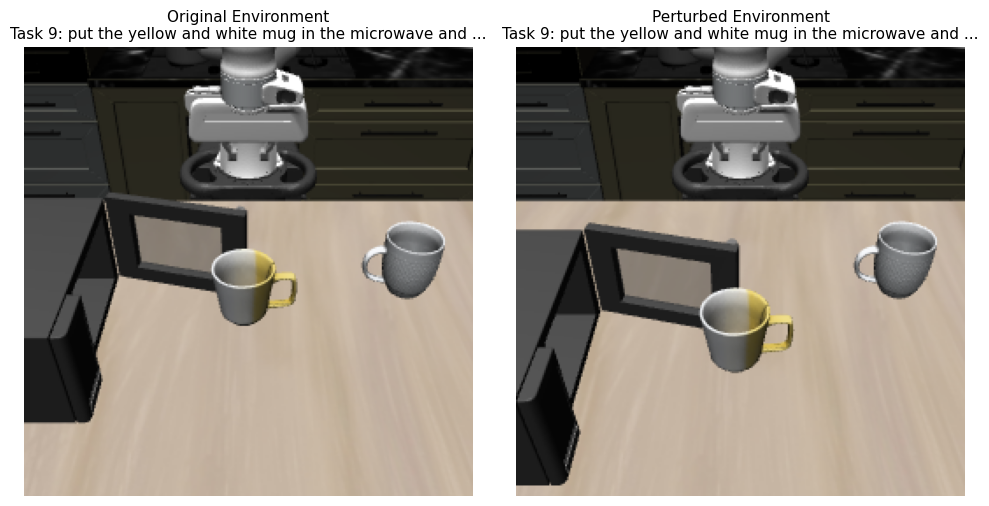


✓ Visualization completed


In [21]:
# ============= Visualization Configuration =============
# Specify the task suite and task ID to visualize
vis_task_suite_name = "libero_10"  # Can modify to other task suite
vis_task_id = 9  # Can modify to 0-9
vis_bddl_suffix = "_displacement"  # Modified BDDL folder suffix

# ============= Load Task and File Paths =============
# Load task suite
vis_benchmark_dict = benchmark.get_benchmark_dict()
vis_task_suite = vis_benchmark_dict[vis_task_suite_name]()

# Get task information
vis_task = vis_task_suite.get_task(vis_task_id)
vis_task_description = vis_task.language

print(f"Visualizing Task {vis_task_id}: {vis_task_description}")
print("="*80)

# Original BDDL file path
original_bddl_path = os.path.join(
    get_libero_path("bddl_files"), 
    vis_task.problem_folder, 
    vis_task.bddl_file
)

# Modified BDDL file path
perturbed_bddl_path = os.path.join(
    get_libero_path("bddl_files"),
    vis_task.problem_folder + vis_bddl_suffix,
    vis_task.bddl_file
)

print(f"Original BDDL: {original_bddl_path}")
print(f"Perturbed BDDL: {perturbed_bddl_path}")

# Check if the modified file exists
if not os.path.exists(perturbed_bddl_path):
    print(f"\nWarning: Perturbed BDDL file does not exist: {perturbed_bddl_path}")
    print("Please run the batch processing cell first, or check if vis_bddl_suffix is correct")
else:
    # ============= Create Environments and Visualize =============
    # Create original environment
    env_original = OffScreenRenderEnv(
        bddl_file_name=original_bddl_path,
        camera_heights=256,
        camera_widths=256
    )
    env_original.seed(random_seed)
    obs_original = env_original.reset()
    img_original = get_libero_image(obs_original, 224)
    
    # Create perturbed environment
    env_perturbed = OffScreenRenderEnv(
        bddl_file_name=perturbed_bddl_path,
        camera_heights=256,
        camera_widths=256
    )
    env_perturbed.seed(random_seed)
    obs_perturbed = env_perturbed.reset()
    img_perturbed = get_libero_image(obs_perturbed, 224)
    
    # Display side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(img_original)
    axes[0].set_title(f"Original Environment\nTask {vis_task_id}: {vis_task_description[:50]}...", fontsize=11)
    axes[0].axis('off')
    
    axes[1].imshow(img_perturbed)
    axes[1].set_title(f"Perturbed Environment\nTask {vis_task_id}: {vis_task_description[:50]}...", fontsize=11)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Cleanup
    env_original.close()
    env_perturbed.close()
    
    print("\n✓ Visualization completed")


## （可选）查看生成的 BDDL 文件内容


In [ ]:
# ============= 查看 BDDL 文件配置 =============
# 指定要查看的任务套件和任务 ID
inspect_task_suite_name = "libero_10"  # 可修改为其他 task suite
inspect_task_id = 0  # 可修改为 0-9
inspect_bddl_suffix = "_displacement"  # 修改后的 BDDL 文件夹后缀

# ============= 加载任务和文件路径 =============
# 加载任务套件
inspect_benchmark_dict = benchmark.get_benchmark_dict()
inspect_task_suite = inspect_benchmark_dict[inspect_task_suite_name]()

# 获取任务信息
inspect_task = inspect_task_suite.get_task(inspect_task_id)

# 修改后的 BDDL 文件路径
inspect_bddl_path = os.path.join(
    get_libero_path("bddl_files"),
    inspect_task.problem_folder + inspect_bddl_suffix,
    inspect_task.bddl_file
)

print(f"查看任务 {inspect_task_id} 的 BDDL 文件内容:")
print(f"文件路径: {inspect_bddl_path}")
print("="*80)

# 检查文件是否存在
if not os.path.exists(inspect_bddl_path):
    print(f"\n警告: BDDL 文件不存在: {inspect_bddl_path}")
    print("请先运行批量处理任务的 cell，或检查 inspect_bddl_suffix 是否正确")
else:
    with open(inspect_bddl_path, 'r') as f:
        content = f.read()
    
    # 显示前 60 行
    lines = content.split('\n')
    for i, line in enumerate(lines[:60]):
        print(f"{i+1:3d}: {line}")
    
    if len(lines) > 60:
        print(f"... (还有 {len(lines) - 60} 行)")


## 使用说明

### 参数说明

1. **perturb_obj_of_interest**: 
   - `True`: 从任务的关键物体（obj_of_interest）中选择要扰动的物体
   - `False`: 从其他非关键物体中选择

2. **num_objects_to_perturb**: 每个任务扰动的物体数量

3. **perturbation_config**:
   - `direction`: 扰动方向
     - `"x"`: 仅 x 方向（控制上下，正往下，负往上）
     - `"y"`: 仅 y 方向（控制左右，正往左，负往右）
     - `"xy"`: 同时在 x 和 y 方向
   - `displacement`: 位移量
     - 单方向: 使用数值，如 `0.1`
     - xy 方向: 使用列表，如 `[0.1, 0.1]` 表示 `[dx, dy]`

4. **use_random_perturbation**: 
   - `True`: 使用随机扰动（在 random_range 指定的范围内）
   - `False`: 使用固定扰动值

5. **bddl_folder_suffix**: BDDL 文件保存路径后缀
   - 文件将保存在 `get_libero_path("bddl_files") / (task.problem_folder + suffix)`
   - 例如：`libero_10` + `_displacement` -> `libero_10_displacement`
   - 文件名保持与原始 BDDL 文件相同

6. **初始状态生成参数**:
   - `num_inits`: 每个任务生成的初始状态数量（默认 50）
   - `camera_height` / `camera_width`: 相机尺寸（默认 128x128）
   - `init_files_base_dir`: 初始状态文件保存的基础目录（默认 `/hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/init_files`）
   - 生成的 `.pruned_init` 文件将保存在 `init_files_base_dir/(problem_folder + suffix)/` 目录下
   - 例如：`init_files/libero_10_displacement/*.pruned_init`

### 文件保存示例

**BDDL 文件：**

如果原始 BDDL 文件路径是：
```
/path/to/bddl_files/libero_10/KITCHEN_SCENE3_turn_on_the_stove.bddl
```

设置 `bddl_folder_suffix = "_displacement"` 后，新文件将保存在：
```
/path/to/bddl_files/libero_10_displacement/KITCHEN_SCENE3_turn_on_the_stove.bddl
```

**初始状态文件：**

对应的初始状态文件将保存在：
```
/hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/init_files/libero_10_displacement/KITCHEN_SCENE3_turn_on_the_stove.pruned_init
```

### 完整工作流程

1. **配置扰动参数**（Cell 4）：设置任务套件、扰动对象、扰动方向和大小、BDDL 文件夹后缀
2. **批量处理任务**（Cell 9）：生成扰动后的 BDDL 文件
3. **可视化对比**（Cell 13，可选）：对比原始环境和扰动后的环境
4. **查看 BDDL 文件**（Cell 15，可选）：检查生成的 BDDL 文件内容
5. **生成初始状态**（Cell 18-20，可选）：为扰动后的 BDDL 文件生成 .pruned_init 文件

### 示例配置

```python
# 示例 1: 扰动关键物体，固定位移
perturb_obj_of_interest = True
num_objects_to_perturb = 1
perturbation_config = {
    "direction": "y",
    "displacement": 0.15
}
use_random_perturbation = False
bddl_folder_suffix = "_displacement"

# 示例 2: 扰动其他物体，随机位移
perturb_obj_of_interest = False
num_objects_to_perturb = 3
perturbation_config = {
    "direction": "xy",
    "displacement": [0, 0]  # 会被随机值覆盖
}
use_random_perturbation = True
random_range = {
    "x": [-0.2, 0.2],
    "y": [-0.2, 0.2]
}
bddl_folder_suffix = "_random_perturb"
```


## （可选）生成初始状态文件

为扰动后的 BDDL 文件生成初始状态文件（.pruned_init），用于后续评估。


In [22]:
# ============= 生成初始状态配置 =============
# 指定要生成初始状态的任务套件
init_task_suite_name = "libero_10"  # 可修改为其他 task suite
init_bddl_suffix = "_displacement"  # 对应的 BDDL 文件夹后缀

# 初始状态生成参数
num_inits = 50  # 每个任务生成的初始状态数量
camera_height = 128  # 相机高度
camera_width = 128  # 相机宽度

# 初始状态文件保存路径（固定在 init_files 目录下）
init_files_base_dir = "/hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/init_files"

print("=" * 80)
print("生成初始状态文件配置")
print("=" * 80)
print(f"任务套件: {init_task_suite_name}")
print(f"BDDL 文件夹后缀: {init_bddl_suffix}")
print(f"每个任务生成初始状态数量: {num_inits}")
print(f"相机尺寸: {camera_height}x{camera_width}")
print(f"初始状态文件保存目录: {init_files_base_dir}")
print("=" * 80)


生成初始状态文件配置
任务套件: libero_10
BDDL 文件夹后缀: _displacement
每个任务生成初始状态数量: 50
相机尺寸: 128x128
初始状态文件保存目录: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/init_files


In [23]:
# 初始状态生成函数已移至 utils_displacement.py
# 导入: generate_init_states_for_bddl

print("初始状态生成函数已从 utils_displacement.py 导入！")


初始状态生成函数已从 utils_displacement.py 导入！


In [24]:
# ============= 批量生成初始状态 =============
# 加载任务套件
init_benchmark_dict = benchmark.get_benchmark_dict()
init_task_suite = init_benchmark_dict[init_task_suite_name]()

# 获取第一个任务以确定 problem_folder
first_task = init_task_suite.get_task(0)
bddl_dir = os.path.join(
    get_libero_path("bddl_files"),
    first_task.problem_folder + init_bddl_suffix
)

# 输出目录：init_files/problem_folder_suffix/
# 例如：init_files/libero_10_displacement/
output_dir = os.path.join(
    init_files_base_dir,
    first_task.problem_folder + init_bddl_suffix
)

print(f"\nBDDL 文件目录: {bddl_dir}")
print(f"初始状态文件输出目录: {output_dir}")
print("=" * 80)

# 检查目录是否存在
if not os.path.exists(bddl_dir):
    print(f"\n警告: BDDL 目录不存在: {bddl_dir}")
    print("请先运行批量处理任务的 cell 生成 BDDL 文件")
else:
    # 获取目录下所有 BDDL 文件
    bddl_files = list(Path(bddl_dir).glob("*.bddl"))
    print(f"\n找到 {len(bddl_files)} 个 BDDL 文件")
    
    if len(bddl_files) == 0:
        print("警告: 未找到任何 BDDL 文件")
    else:
        # 创建输出目录
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        
        # 批量生成初始状态
        print("\n开始批量生成初始状态...")
        print("=" * 80)
        
        init_results = []
        
        for bddl_file in bddl_files:
            print(f"\n处理: {bddl_file.name}")
            try:
                output_file = generate_init_states_for_bddl(
                    bddl_file_path=str(bddl_file),
                    output_dir=output_dir,
                    num_inits=num_inits,
                    height=camera_height,
                    width=camera_width
                )
                
                init_results.append({
                    "bddl_file": str(bddl_file),
                    "output_file": output_file,
                    "status": "success" if output_file else "failed"
                })
                
            except Exception as e:
                print(f"  ✗ 处理失败: {e}")
                init_results.append({
                    "bddl_file": str(bddl_file),
                    "status": "failed",
                    "error": str(e)
                })
        
        # 打印摘要
        print("\n" + "=" * 80)
        print("初始状态生成完成！")
        print("=" * 80)
        
        success_count = sum(1 for r in init_results if r.get("status") == "success")
        failed_count = sum(1 for r in init_results if r.get("status") == "failed")
        
        print(f"\n生成摘要:")
        print(f"  总文件数: {len(init_results)}")
        print(f"  成功: {success_count}")
        print(f"  失败: {failed_count}")
        print(f"\n所有 .pruned_init 文件已保存到: {output_dir}")
        
        # 显示成功生成的文件
        if success_count > 0:
            print("\n成功生成的初始状态文件:")
            print("-" * 80)
            for r in init_results:
                if r.get("status") == "success":
                    print(f"  ✓ {r['output_file']}")
        
        # 显示失败的文件
        if failed_count > 0:
            print("\n失败的文件:")
            print("-" * 80)
            for r in init_results:
                if r.get("status") == "failed":
                    print(f"  ✗ {r['bddl_file']}: {r.get('error', 'Unknown error')}")


[info] Applying task order index 0 (permutation: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) for benchmark 'libero_10' (10 tasks).
[Warning]: datasets path /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/../datasets does not exist!

BDDL 文件目录: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10_displacement
初始状态文件输出目录: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/init_files/libero_10_displacement

找到 10 个 BDDL 文件

开始批量生成初始状态...

处理: KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it.bddl
  生成任务 KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it 的初始状态...
    ✓ 成功保存 50 个状态到: /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/init_files/libero_10_displacement/KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it.pruned_init

处理: KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it.bddl
  生成任务 KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it 的初始状态...
    ✓ 成功保存 50 个状